In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/youtube-analytics-data/youtube_recommendation_dataset -.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("/kaggle/input/youtube-analytics-data/youtube_recommendation_dataset -.csv")


#  EDA

In [7]:
df.head()

,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1405647,140463,9063,0,PT1M51S,hd,False,0.106375,0.099928,0.006448,111,1
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,2776847,26801,6684,0,PT1M,hd,True,0.012059,0.009652,0.002407,60,0
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1189857,16174,1827,0,PT18M2S,hd,False,0.015129,0.013593,0.001535,1082,0
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,THEBLACKLABEL,2025-11-17 09:00:07+00:00,10,5319161,0,12869,0,PT3M23S,hd,True,0.002419,0.000000,0.002419,203,1
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,PlayOverwatch,2025-11-17 17:00:06+00:00,20,597542,41742,4728,0,PT3M35S,hd,True,0.077768,0.069856,0.007912,215,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537 entries, 0 to 536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    537 non-null    object 
 1   channel_title            537 non-null    object 
 2   published_at             537 non-null    object 
 3   category_id              537 non-null    int64  
 4   view_count               537 non-null    int64  
 5   like_count               537 non-null    int64  
 6   comment_count            537 non-null    int64  
 7   favorite_count           537 non-null    int64  
 8   duration                 537 non-null    object 
 9   definition               537 non-null    object 
 10  caption                  537 non-null    bool   
 11  engagement_rate          537 non-null    float64
 12  likes_to_views_ratio     537 non-null    float64
 13  comments_to_views_ratio  537 non-null    float64
 14  duration_seconds         5

In [10]:
df.describe()

,category_id,view_count,like_count,comment_count,favorite_count,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
count,537.000000,5.370000e+02,5.370000e+02,537.000000,537.0,537.000000,537.000000,537.000000,537.000000,537.000000
mean,22.456238,2.145752e+07,4.336044e+05,7125.700186,0.0,0.028722,0.027692,0.001030,4802.746741,934.050279
std,5.854776,4.015200e+07,8.386711e+05,36075.115032,0.0,0.020608,0.019708,0.002166,13748.249437,904.546132
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.676921e+06,5.559100e+04,1018.000000,0.0,0.015579,0.015301,0.000115,52.000000,261.000000
50%,24.000000,6.385911e+06,1.550550e+05,2354.000000,0.0,0.024368,0.023565,0.000398,390.000000,658.000000
75%,27.000000,2.270604e+07,4.631890e+05,5925.000000,0.0,0.037366,0.036282,0.000954,1639.000000,1363.000000
max,28.000000,3.697310e+08,1.087934e+07,810641.000000,0.0,0.215744,0.199095,0.026031,105227.000000,4772.000000


In [13]:
df.shape

(537, 16)

In [14]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Title                      0
channel_title              0
published_at               0
category_id                0
view_count                 0
like_count                 0
comment_count              0
favorite_count             0
duration                   0
definition                 0
caption                    0
engagement_rate            0
likes_to_views_ratio       0
comments_to_views_ratio    0
duration_seconds           0
video_age_days             0
dtype: int64


In [15]:
df.columns

Index(['Title', 'channel_title', 'published_at', 'category_id', 'view_count',
       'like_count', 'comment_count', 'favorite_count', 'duration',
       'definition', 'caption', 'engagement_rate', 'likes_to_views_ratio',
       'comments_to_views_ratio', 'duration_seconds', 'video_age_days'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

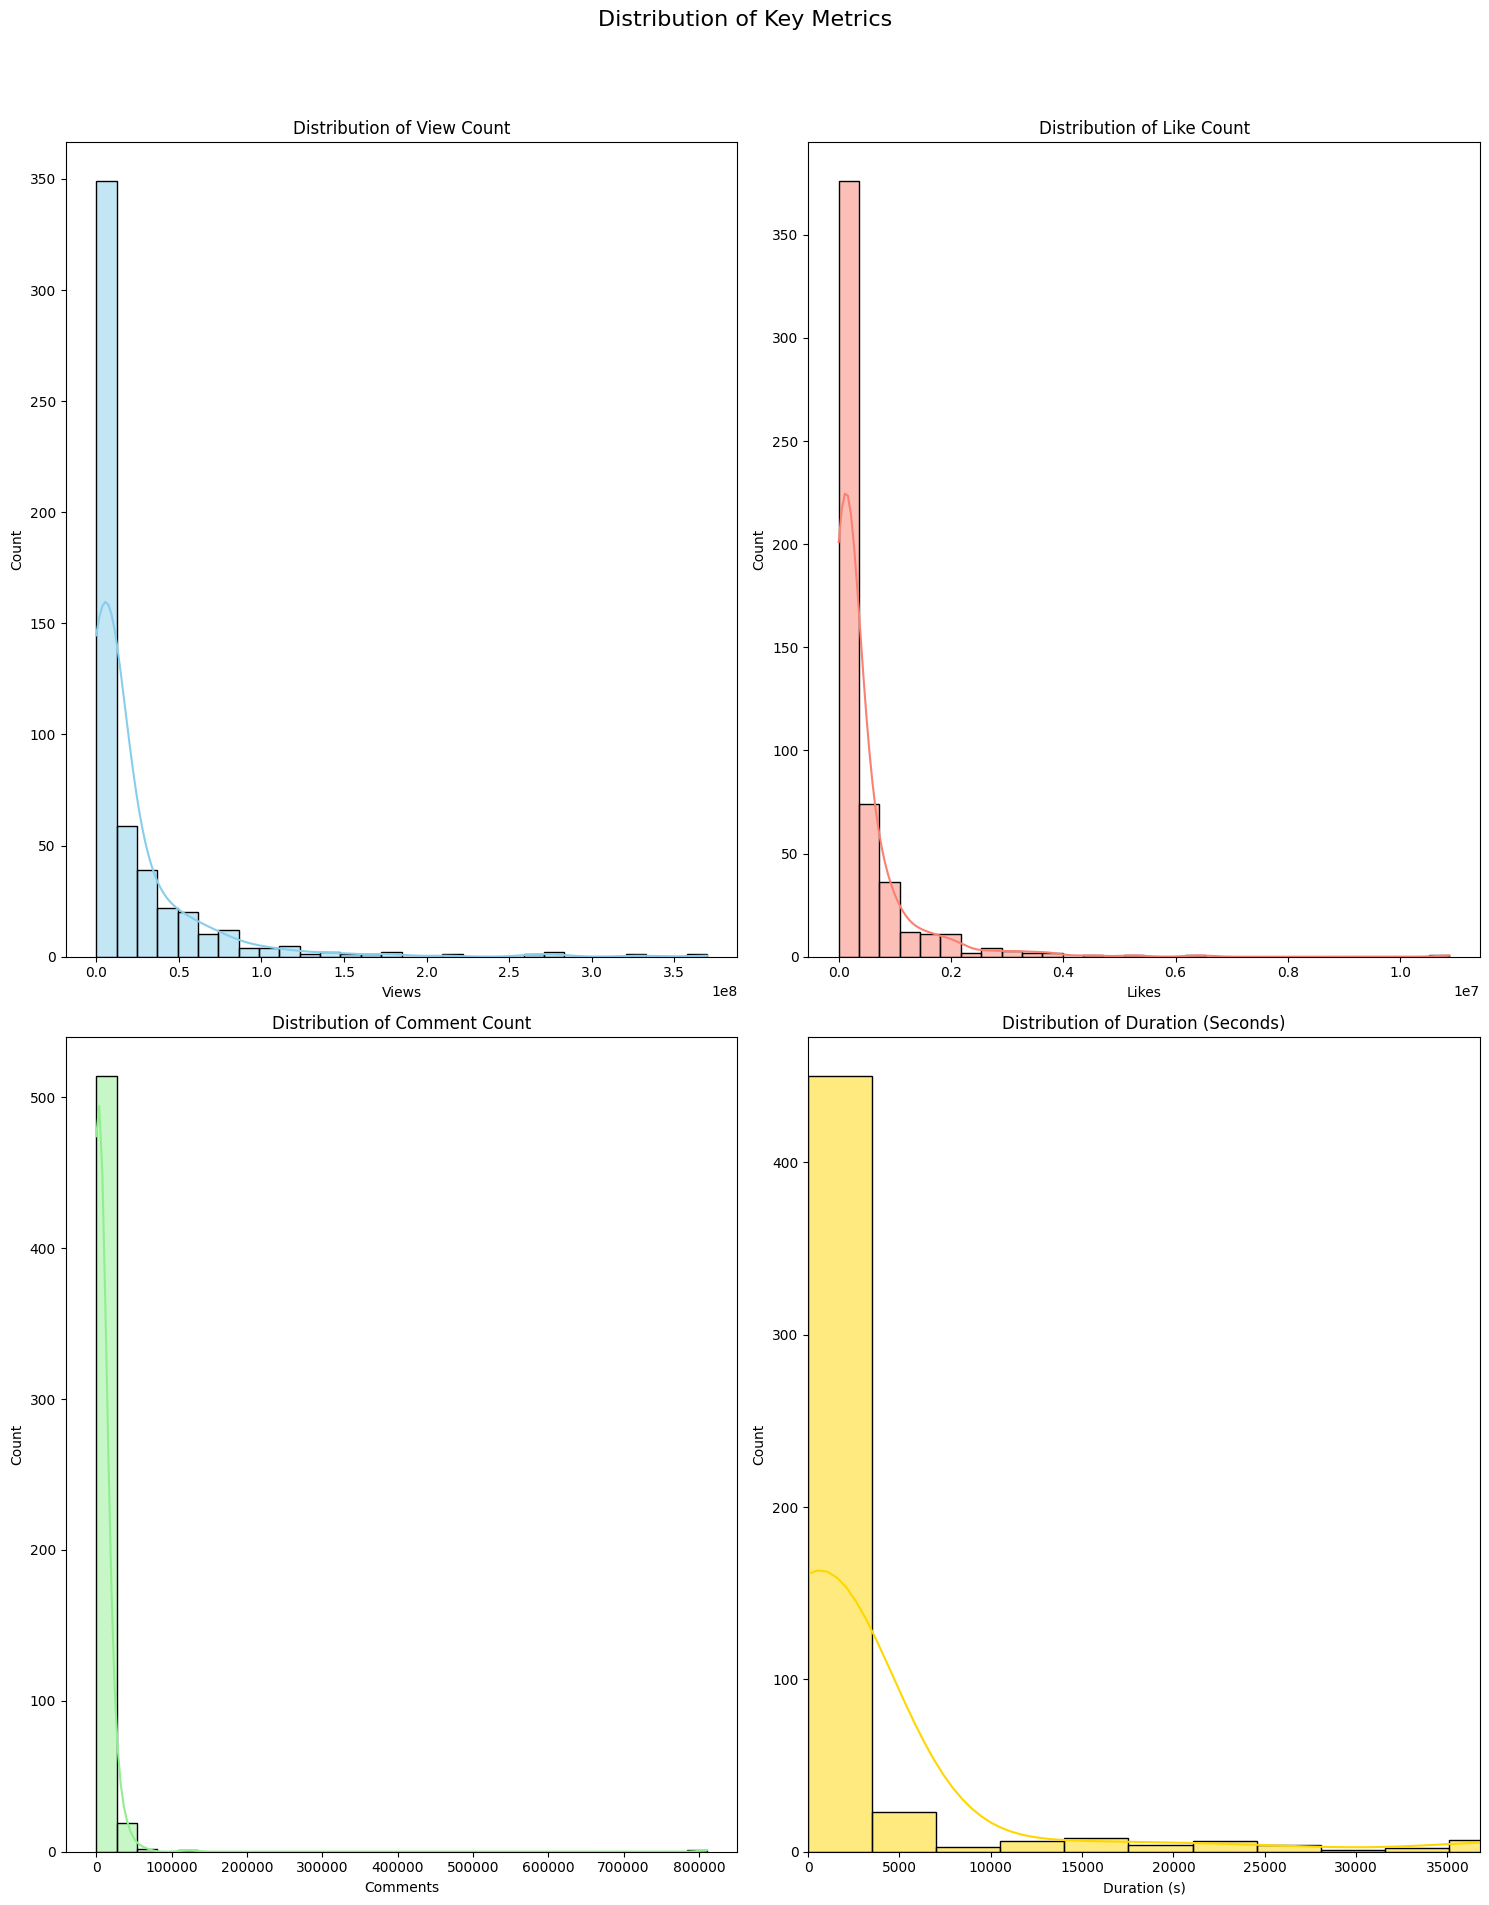

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 20))
fig.suptitle('Distribution of Key Metrics', fontsize=16)

sns.histplot(df['view_count'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of View Count')
axes[0, 0].set_xlabel('Views')

sns.histplot(df['like_count'], bins=30, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Like Count')
axes[0, 1].set_xlabel('Likes')

sns.histplot(df['comment_count'], bins=30, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Comment Count')
axes[1, 0].set_xlabel('Comments')

sns.histplot(df['duration_seconds'], bins=30, kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Duration (Seconds)')
axes[1, 1].set_xlabel('Duration (s)')
axes[1, 1].set_xlim(0, df['duration_seconds'].quantile(0.95)) # Limit x-axis for better visibility

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

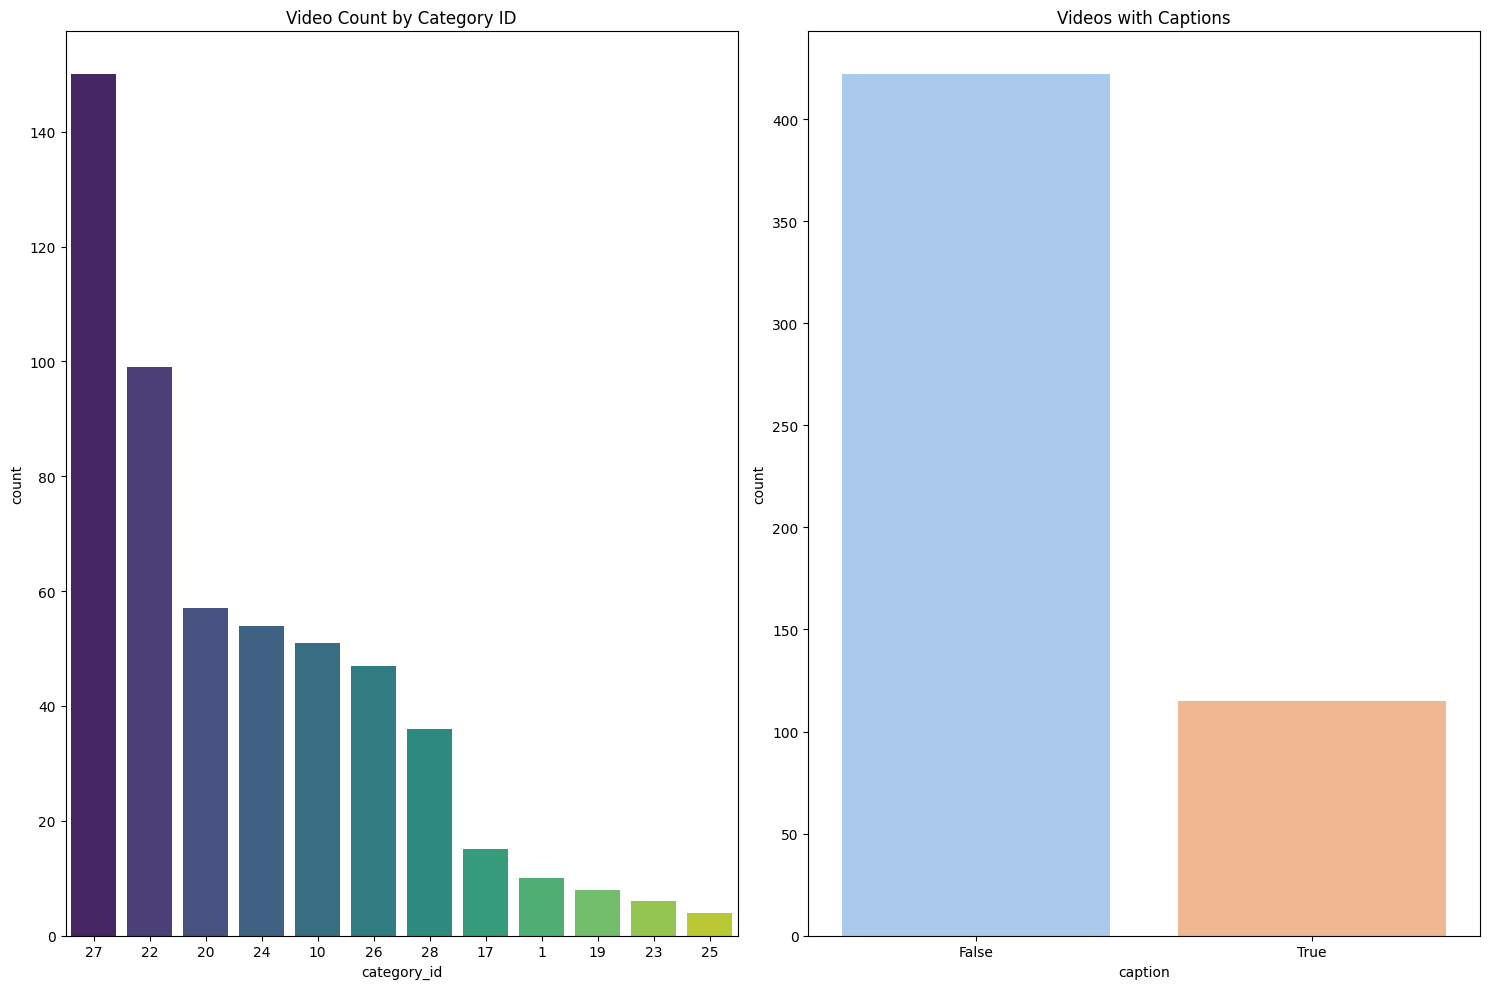

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.countplot(x='category_id', data=df, ax=axes[0], palette='viridis', order=df['category_id'].value_counts().index)
axes[0].set_title('Video Count by Category ID')

sns.countplot(x='caption', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Videos with Captions')

plt.tight_layout()


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Text(0.5, 1.0, 'Correlation Heatmap')

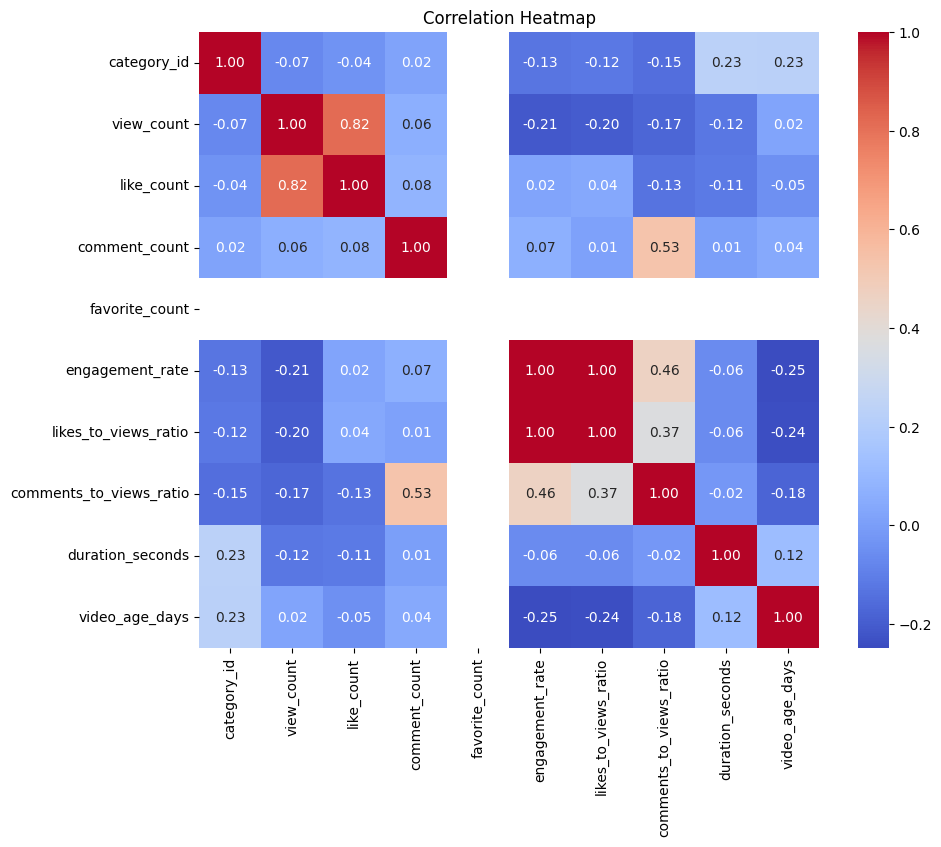

In [22]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

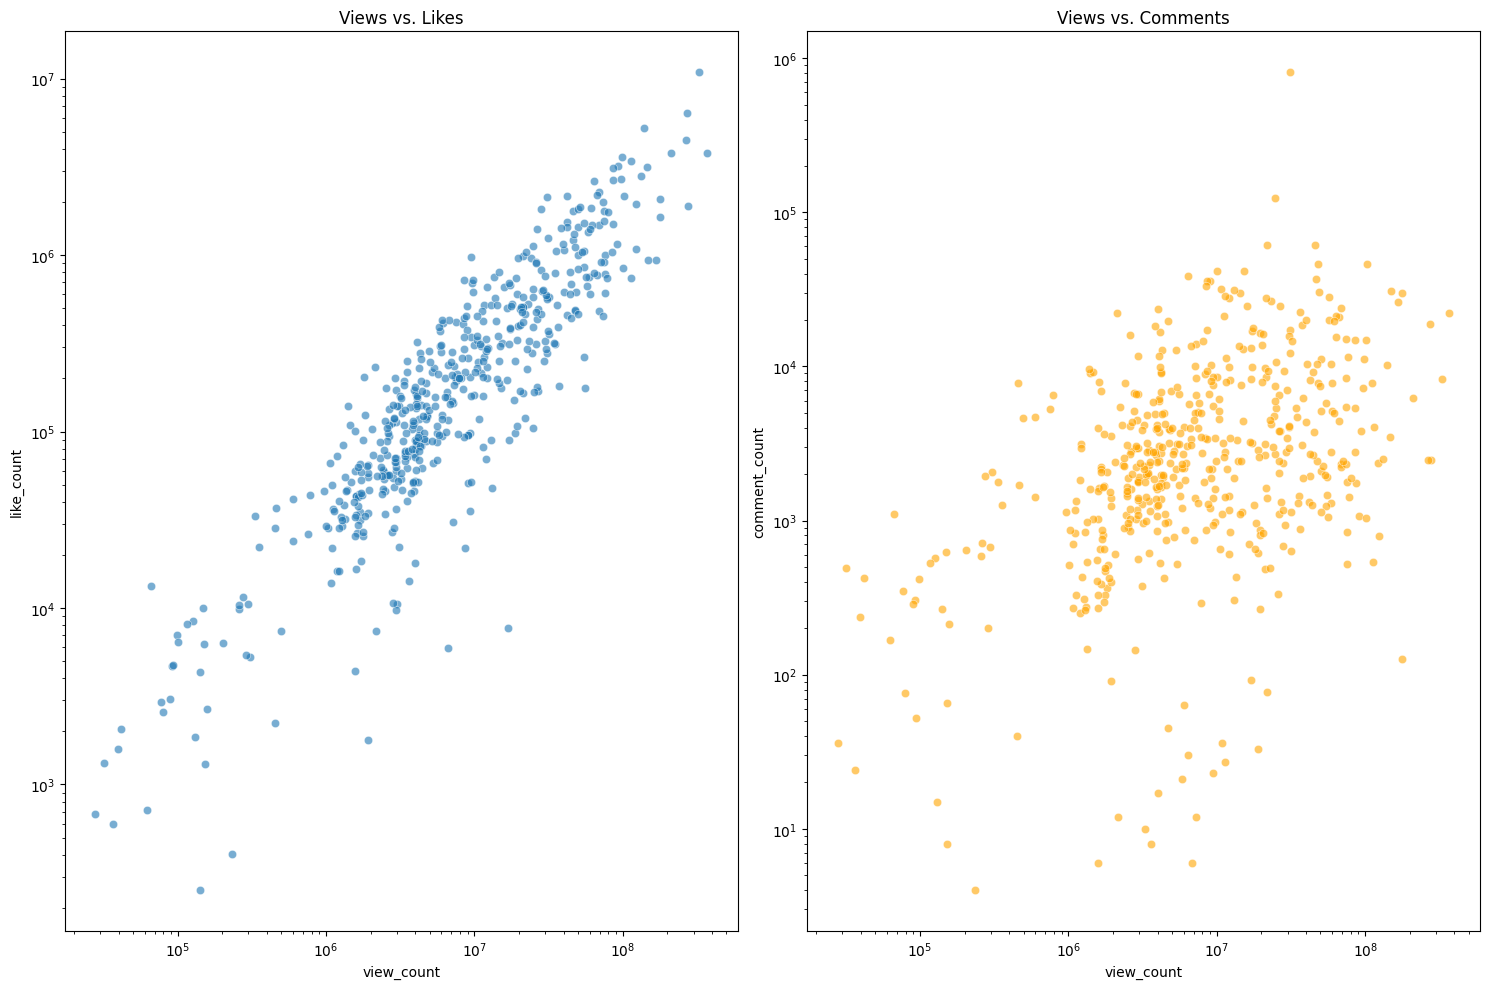

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.scatterplot(x='view_count', y='like_count', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs. Likes')
axes[0].set_xscale('log') # Log scale for better visualization
axes[0].set_yscale('log')

sns.scatterplot(x='view_count', y='comment_count', data=df, ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('Views vs. Comments')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()

Text(0.5, 1.0, 'View Count Distribution by Category')

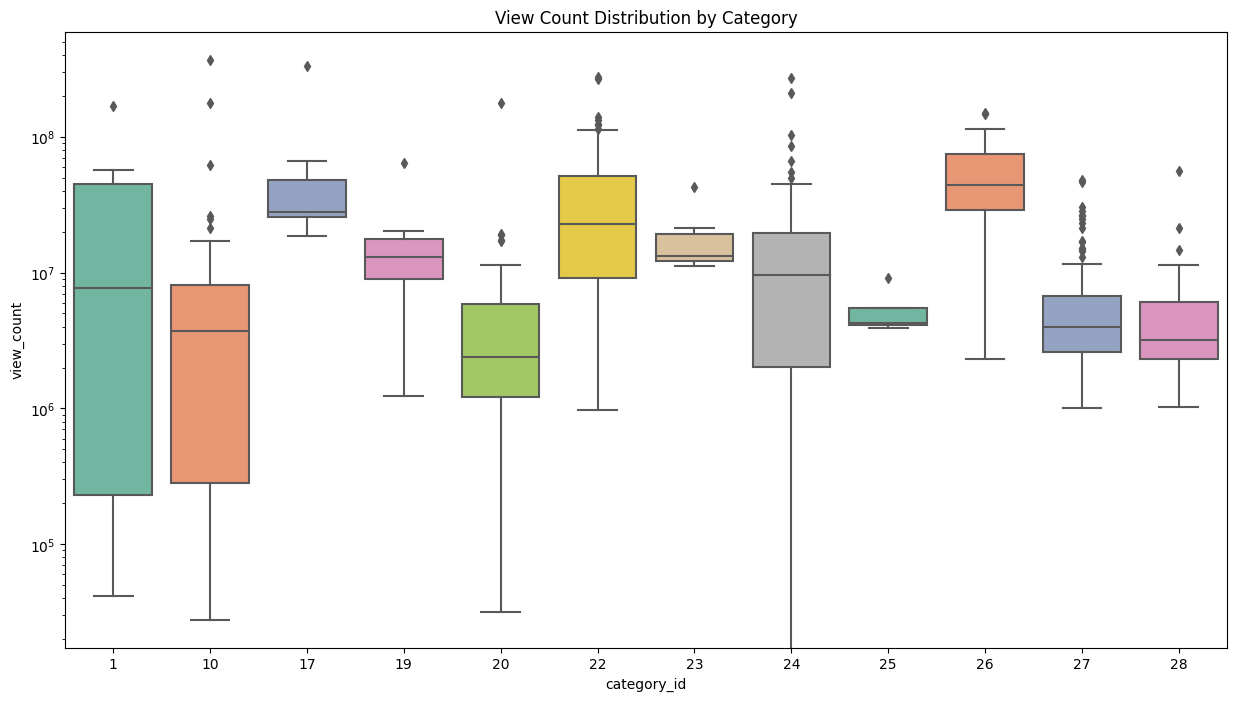

In [30]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='category_id', y='view_count', data=df, palette='Set2')
plt.yscale('log')
plt.title('View Count Distribution by Category')

#   PreProcessing 

In [33]:
STOPWORDS = set(stopwords.words('english'))
lemm = WordNetLemmatizer()
url_re = re.compile(r"https?://\S+|www\.\S+")

In [34]:
def clean_text(t):
    if pd.isna(t): return ""
    t = str(t).lower()
    t = url_re.sub("", t)
    t = re.sub(r"[^a-zA-Z0-9 ]", " ", t)
    tokens = nltk.word_tokenize(t)
    tokens = [lemm.lemmatize(w) for w in tokens if w not in STOPWORDS]
    return " ".join(tokens)

In [40]:
df['Title_clean'] = df['Title'].progress_apply(clean_text)
df['view_count'] = df['view_count'].progress_apply(clean_text)


  0%|          | 0/537 [00:00<?, ?it/s]

  0%|          | 0/537 [00:00<?, ?it/s]

In [41]:
df['Title_len'] = df['Title'].fillna("").apply(lambda x: len(x.split()))
df['view_count'] = df['view_count'].fillna("").apply(lambda x: len(x.split()))


In [47]:
df['like_count'] = df['like_count'].fillna(0)
df['comment_count'] = df['comment_count'].fillna(0)
df['view_count'] = df['view_count'].fillna(1)
df['engagement_rate'] = (df['like_count'] + df['comment_count']) / df['view_count']


In [49]:
def sentiment_score(c):
    if pd.isna(c): return 0
    if not isinstance(c, str): return 0
    vs = SentimentIntensityAnalyzer().polarity_scores(c)
    return vs['compound']

df['comment_count'] = df['comment_count'].progress_apply(sentiment_score)

  0%|          | 0/537 [00:00<?, ?it/s]

In [50]:
df.head()

,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days,Title_clean,Title_len
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1,140463,0,0,PT1M51S,hd,False,149526.0,0.099928,0.006448,111,1,la perversa x la insuperable x alofoke music x...,13
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,1,26801,0,0,PT1M,hd,True,33485.0,0.009652,0.002407,60,0,moana official teaser,4
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1,16174,0,0,PT18M2S,hd,False,18001.0,0.013593,0.001535,1082,0,0 1 trillion fishing steal brainrot,10
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,THEBLACKLABEL,2025-11-17 09:00:07+00:00,10,1,0,0,0,PT3M23S,hd,True,12869.0,0.000000,0.002419,203,1,allday project one time v,7
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,PlayOverwatch,2025-11-17 17:00:06+00:00,20,1,41742,0,0,PT3M35S,hd,True,46470.0,0.069856,0.007912,215,0,la lupa vendetta hero trailer overwatch 2,9


In [ ]:
def clean_text(text):
    text = text.lower()                             # حروف صغيرة
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # حذف الروابط
    text = re.sub(r"[^a-zA-Z\s]", '', text)         # حروف بس
    text = re.sub(r"\s+", " ", text).strip()        # مسافات زيادة
    return text

df['clean_text'] = df['comment_text'].apply(clean_text)



In [ ]:
X = df['engagement_rate']
y = df['engagement_rate']    

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)



# Train Model

In [ ]:
Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train.toarray(), y_train)  # RF needs dense
pred_rf = rf.predict(X_test.toarray())

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


#  Evaluate

In [ ]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
